# Exhaustive enumeration — 3×3 grid, k=3

Enumerates every valid redistricting plan (contiguous districts, equal population)
for a 3×3 grid into 3 districts, then runs the full letters/words/POU pipeline on
the exact uniform distribution over those plans.

## Config

In [2]:
N          = 3        # grid is N×N
K          = 3        # number of districts
NUM_LETTERS = 6       # HCC clusters (letters)
WORD_DEGREE = 5       # beam width for word enumeration
TEMP        = 0.0     # POU temperature

GRAPH_FN = "data/graph/grid_3x3_k3.json"
SAMPLE_FN = "local/output/grid3x3_k3/all_plans.jsonl.gz"
OUT_DIR   = "local/output/grid3x3_k3/processed"

In [3]:
import gzip
import json
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from data import generate_grid_graph, generate_grid_shape
from hierachical import HClusters
from sample import SampleProcessor
from utils import plot_plan, plot_words_centroids
from word import PlanWordBuilder, WordStat

/Users/ag245/Library/CloudStorage/GoogleDrive-annacgilbert@gmail.com/My Drive/Research/gmstrat/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1 — Build the graph

In [4]:
Path("data/graph").mkdir(parents=True, exist_ok=True)
generate_grid_graph(N=N, filename=GRAPH_FN, num_districts=K)

with open(GRAPH_FN) as f:
    graph_data = json.load(f)

gdf = generate_grid_shape(N)

# networkx graph for contiguity checks
G = nx.Graph()
G.add_nodes_from(range(N * N))
for node_idx, neighbors in enumerate(graph_data["adjacency"]):
    for nbr in neighbors:
        G.add_edge(node_idx, nbr["id"])

precinct_strs = [graph_data["nodes"][i]["precinct_id_str"] for i in range(N * N)]
print("Grid nodes:", precinct_strs)

Grid nodes: ['(0,0)', '(0,1)', '(0,2)', '(1,0)', '(1,1)', '(1,2)', '(2,0)', '(2,1)', '(2,2)']


## Step 2 — Enumerate all valid plans

A plan is valid if every district is contiguous and has exactly `N²/K` precincts
(population balance is automatic since all cells have population 1).

The algorithm always assigns the smallest remaining precinct to the next district,
which generates each unordered partition exactly once without needing deduplication.

In [5]:
district_size = (N * N) // K  # precincts per district

def enumerate_plans(remaining, current_districts):
    if len(current_districts) == K - 1:
        last = tuple(sorted(remaining))
        if len(last) == district_size and nx.is_connected(G.subgraph(last)):
            yield current_districts + (last,)
        return
    remaining_sorted = sorted(remaining)
    first = remaining_sorted[0]  # must be in this district — ensures canonical ordering
    for others in combinations(remaining_sorted[1:], district_size - 1):
        district = (first,) + others
        if nx.is_connected(G.subgraph(district)):
            yield from enumerate_plans(
                set(remaining) - set(district),
                current_districts + (district,),
            )

all_plans = list(enumerate_plans(set(range(N * N)), ()))
print(f"Total valid plans: {len(all_plans)}")

Total valid plans: 10


## Step 3 — Visualize all plans

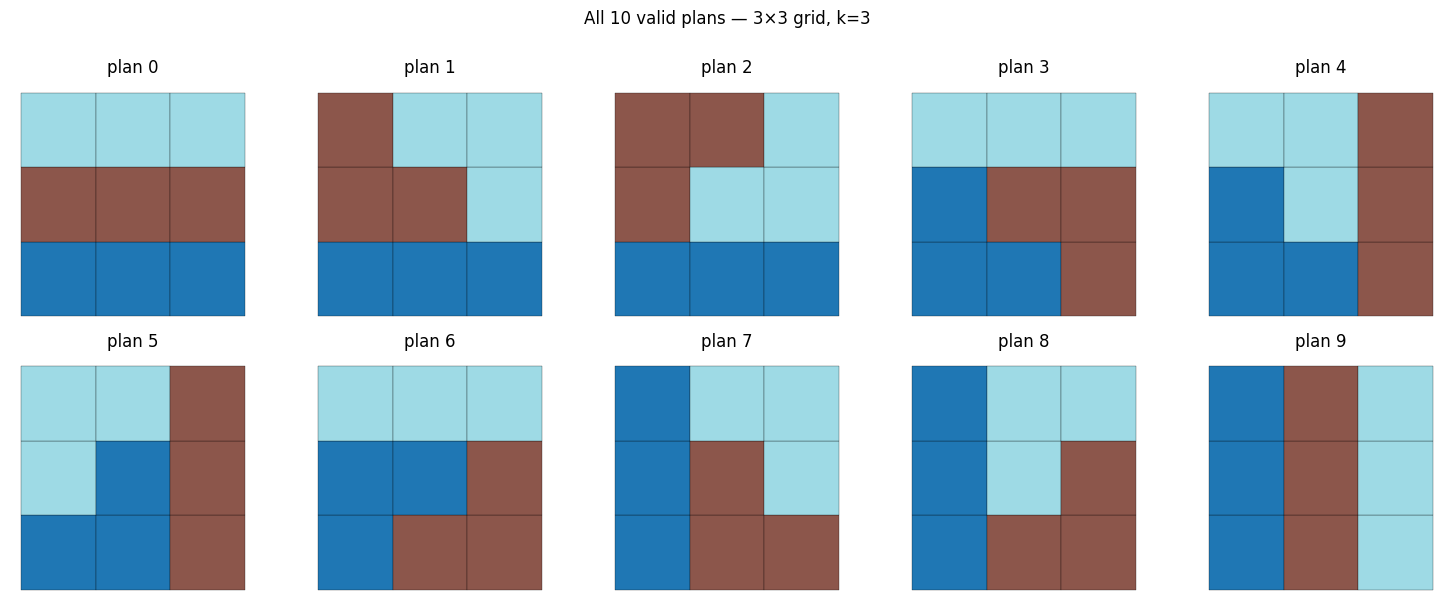

In [6]:
def plan_tuple_to_vector(plan):
    vec = np.zeros(N * N, dtype=int)
    for district_id, district in enumerate(plan):
        for precinct in district:
            vec[precinct] = district_id
    return vec

n_plans = len(all_plans)
ncols = 5
nrows = (n_plans + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
axes = np.array(axes).flatten()

for i, plan in enumerate(all_plans):
    plot_plan(gdf, plan_tuple_to_vector(plan), ax=axes[i])
    axes[i].set_title(f"plan {i}")

for ax in axes[n_plans:]:
    ax.set_visible(False)

plt.suptitle(f"All {n_plans} valid plans — {N}×{N} grid, k={K}", y=1.01)
plt.tight_layout()
plt.show()

## Step 4 — Write plans as JSONL.gz for SampleProcessor

Each plan is written as a single sample step so the existing pipeline can ingest them.
District labels are 1-indexed (SampleProcessor subtracts 1 on read).

In [7]:
Path(SAMPLE_FN).parent.mkdir(parents=True, exist_ok=True)

with gzip.open(SAMPLE_FN, "wt") as f:
    f.write(json.dumps({}) + "\n")               # line 0 — skipped
    f.write(json.dumps({}) + "\n")               # line 1 — skipped
    f.write(json.dumps({"districts": K}) + "\n") # line 2 — header
    for step, plan in enumerate(all_plans, start=1):
        districting = [
            {precinct_strs[precinct]: district_id + 1}  # 1-indexed
            for district_id, district in enumerate(plan)
            for precinct in district
        ]
        f.write(json.dumps({"name": f"step{step * 100}", "districting": districting}) + "\n")

print(f"Wrote {len(all_plans)} plans to {SAMPLE_FN}")

Wrote 10 plans to local/output/grid3x3_k3/all_plans.jsonl.gz


## Step 5 — Process samples and build HCC linkage

In [8]:
sp = SampleProcessor(GRAPH_FN, OUT_DIR)
sp.clean()
sp.process_samples([SAMPLE_FN], max_length=len(all_plans) + 10, min_step=0)
sp.load_processed()

print(f"Unique districts: {len(sp.df_districts)}")
print(f"Unique plans:     {len(sp.df_distributions)}")
sp.df_districts.head()

Reading local/output/grid3x3_k3/all_plans.jsonl.gz


plans: 100%|██████████| 10/10 [00:00<00:00, 9008.38it/s]

Unique districts: 18
Unique plans:     10


,district_str,district_uid
0,0.1.2,0
1,3.4.5,1
2,6.7.8,2
3,3.4.6,3
4,5.7.8,4


In [9]:
sp.load_distance_matrix()
sp.ensure_linkage()
print("Distance matrix and linkage ready.")

100%|██████████| 153/153 [00:00<00:00, 42299.68it/s]

Distance matrix and linkage ready.


## Step 6 — Letters (HCC clusters)

In [10]:
num_letters = min(NUM_LETTERS, len(sp.df_districts) - 1)

hc = HClusters(sp)
hc.update_clusters(num_letters)
hc.kcentroids()

print(f"Using {num_letters} letters.")

  0%|          | 0/50 [00:00<?, ?it/s]

Using 6 letters.


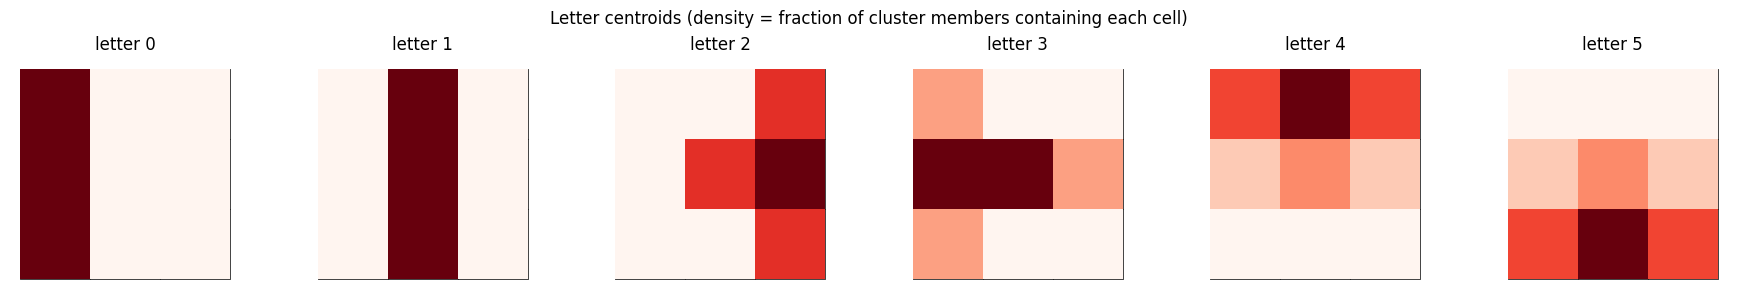

In [11]:
fig, axes = plt.subplots(1, num_letters, figsize=(3 * num_letters, 3))
for i, ax in enumerate(axes):
    gdf.plot(color="lightgrey", ax=ax, edgecolor="black", linewidth=0.5)
    vals = hc.cluster_densities[i]
    gdf.assign(v=vals).plot(column="v", ax=ax, cmap="Reds", vmin=0, vmax=1)
    ax.set_title(f"letter {i}")
    ax.set_axis_off()
plt.suptitle("Letter centroids (density = fraction of cluster members containing each cell)")
plt.tight_layout()
plt.show()

## Step 7 — Words and stationary distribution

In [12]:
pw = PlanWordBuilder(sp, hc, word_degree=WORD_DEGREE, verbose=True, centroid_norm="l1").build()
ws = WordStat(pw, temp=TEMP, verbose=False)

df_stat = ws.stationary_table()
print(f"Distinct words: {len(df_stat)}")
df_stat.head(10)

Enumerating words: 100%|██████████| 10/10 [00:00<00:00, 39494.39it/s]

Distinct words: 19


,word_uid,word_str,word,stationary
0,18,3.4.5,"[3, 4, 5]",0.10
1,8,0.4.5,"[0, 4, 5]",0.10
2,17,2.4.5,"[2, 4, 5]",0.10
3,4,0.2.4,"[0, 2, 4]",0.10
4,5,0.2.5,"[0, 2, 5]",0.10
5,16,2.3.5,"[2, 3, 5]",0.06
6,15,2.3.4,"[2, 3, 4]",0.06
7,0,0.1.2,"[0, 1, 2]",0.06
8,1,0.1.4,"[0, 1, 4]",0.04
9,10,1.2.4,"[1, 2, 4]",0.04


## Step 8 — Every plan with its top word assignment

Since we have the full universe of plans, we can show exactly which word each plan maps to.

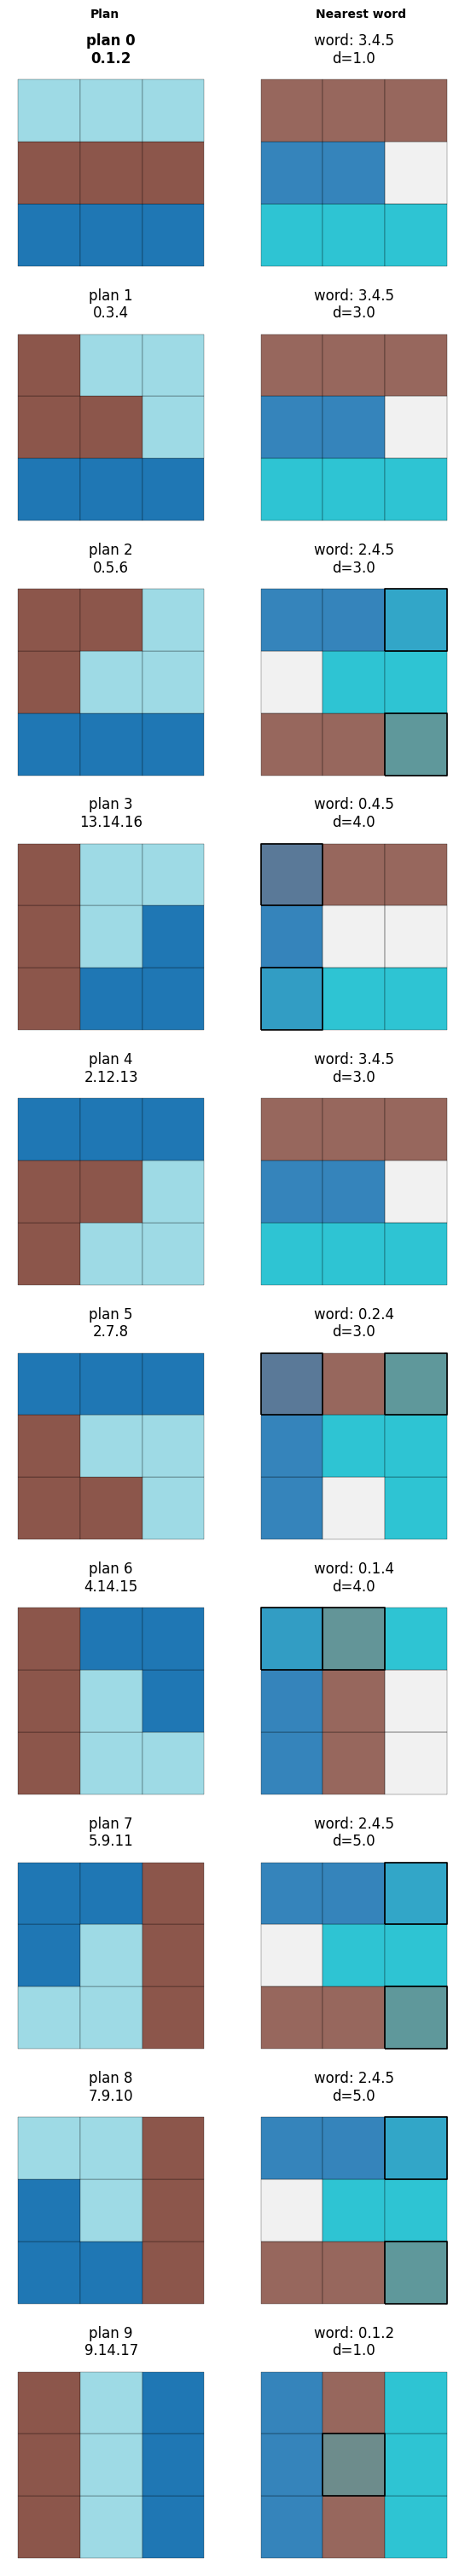

In [13]:
# For each plan, show the plan itself and its nearest word
df_best = (
    pw.df_words
    .sort_values("distance")
    .drop_duplicates(subset=["plan_uid"], keep="first")
    .set_index("plan_uid")
)

n_plans = len(sp.df_distributions)
ncols = 2  # plan | word per row
fig, axes = plt.subplots(n_plans, 2, figsize=(6, 3 * n_plans))

for row_idx, plan_row in sp.df_distributions.reset_index().iterrows():
    plan_uid = plan_row.name if "plan_uid" not in plan_row else plan_row["plan_uid"]
    # left: the actual plan
    ax_plan = axes[row_idx, 0]
    plan_vec = sp.decode_plan_vector(plan_row.plan_vector)
    plot_plan(gdf, plan_vec, ax=ax_plan)
    ax_plan.set_title(f"plan {row_idx}\n{plan_row.plan_str}")

    # right: the nearest word
    ax_word = axes[row_idx, 1]
    if row_idx in df_best.index:
        best = df_best.loc[row_idx]
        plot_words_centroids(gdf, hc.cluster_densities, best.word, ltr=True, ax=ax_word)
        ax_word.set_title(f"word: {best.word_str}\nd={best.distance:.1f}")
    else:
        ax_word.set_visible(False)

axes[0, 0].set_title(axes[0, 0].get_title(), fontweight="bold")
fig.text(0.25, 1.001, "Plan", ha="center", fontweight="bold")
fig.text(0.75, 1.001, "Nearest word", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

## Step 9 — Flux matrix

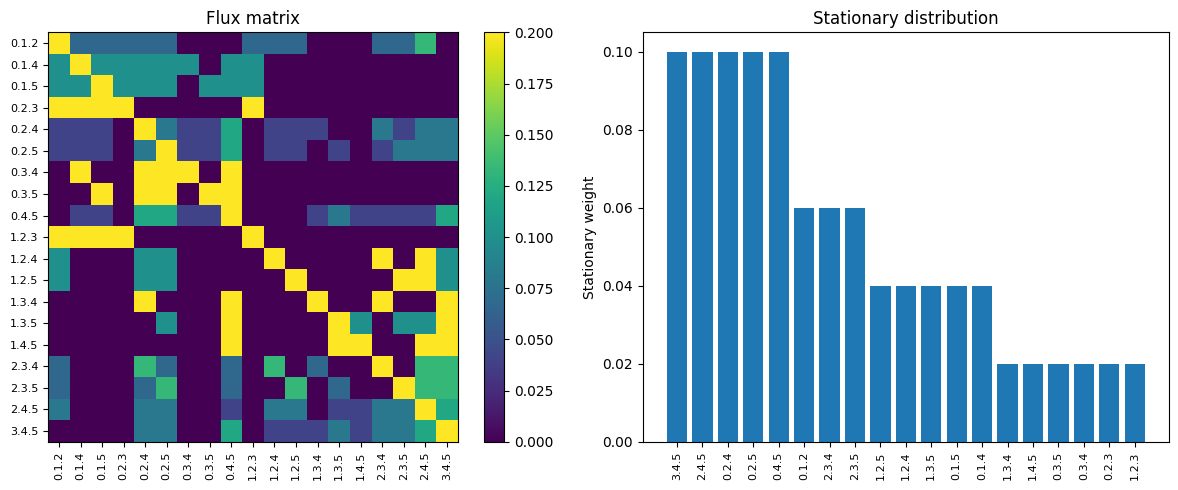

In [14]:
flux = ws.flux_matrix()
labels = ws.stationary_table().sort_values("word_uid")["word_str"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im = axes[0].imshow(flux, cmap="viridis")
axes[0].set_xticks(range(len(labels)))
axes[0].set_yticks(range(len(labels)))
axes[0].set_xticklabels(labels, rotation=90, fontsize=8)
axes[0].set_yticklabels(labels, fontsize=8)
axes[0].set_title("Flux matrix")
plt.colorbar(im, ax=axes[0])

stat = ws.stationary_distribution()
order = np.argsort(stat)[::-1]
axes[1].bar(range(len(stat)), stat[order])
axes[1].set_xticks(range(len(stat)))
axes[1].set_xticklabels([labels[i] for i in order], rotation=90, fontsize=8)
axes[1].set_ylabel("Stationary weight")
axes[1].set_title("Stationary distribution")

plt.tight_layout()
plt.show()